# RecoveryLens — Complete ML Pipeline

Post-stroke risk prediction with explanations, built on the International Stroke Trial (IST-1).

**Before running**

1. Put `IST_corrected.csv` in the same folder as this notebook.
2. Optional: put `IST3_clean.csv` alongside it for the external-validation section.
3. `pip install pandas numpy scikit-learn xgboost lightgbm catboost shap statsmodels matplotlib joblib`
   (macOS: `brew install libomp` first, or xgboost/lightgbm will fail to load.)

**What this produces**

| Artifact | Purpose |
|---|---|
| `outputs/*.md`, `outputs/*.json` | Reports + metrics for the Evidence screen |
| `models/final_*.pkl` | Calibrated models the API will load |
| `models/explainer_*.pkl` | SHAP explainers |
| `outputs/MODEL_CARD.md` | TRIPOD+AI-style documentation |

**Run all cells top to bottom.** Section 14 prints a single summary block — paste that back for review.

## 1. Setup

In [1]:
import json, warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
N_BOOTSTRAP = 1000
CITL_TOLERANCE = 0.15          # |CITL| above this considered material
FAST = False                   # True = tiny grids for a quick smoke test

DATA = Path("data/IST_corrected.csv")
IST3 = Path("data/IST3_clean.csv")  # optional
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
MODELS = Path("models"); MODELS.mkdir(exist_ok=True)

report = []
def log(line=""):
    print(line)
    report.append(str(line))

print("Setup OK")

Setup OK


## 2. Load and reconcile against the data dictionary

`latin-1`, not `utf-8` — the file has non-UTF8 bytes in free-text comment fields.

Four corrections, all documented in the published variable table:

| Issue | Fix | Why |
|---|---|---|
| `RXHEP` has 245 rows coded `H` | merge into `M` | dictionary: pilot phase recorded medium dose as H |
| `FAP` has one lowercase `n` | normalise to `N` | data entry slip |
| `RATRIAL` missing for 984 rows | own `unknown` category | not coded in pilot phase — missing *by design*, not at random |
| `OCCODE` has undocumented code `0` | exclude with code `9` | 97 rows, not in the dictionary |

In [2]:
df = pd.read_csv(DATA, low_memory=False, encoding="latin-1")

log("# RecoveryLens — Pipeline Report\n")
log("## 1. Load\n")
log(f"- Rows: **{len(df):,}** (expected 19,435)")
log(f"- Columns: **{len(df.columns)}** (expected 112)")
assert len(df) == 19435, "Row count mismatch — wrong file version?"

pilot_mask = df["RATRIAL"].isna()
n_h = int((df["RXHEP"] == "H").sum())
n_h_pilot = int(((df["RXHEP"] == "H") & pilot_mask).sum())
df["RXHEP"] = df["RXHEP"].replace({"H": "M"})

n_lower = int((df["FAP"] == "n").sum())
df["FAP"] = df["FAP"].replace({"n": "N"})

log("\n## 2. Corrections applied\n")
log(f"- **RXHEP**: merged `H` -> `M` ({n_h} rows; {n_h_pilot} in pilot phase)")
log(f"- **FAP**: lowercase `n` -> `N` ({n_lower} row)")
log(f"- **RATRIAL**: {int(pilot_mask.sum())} missing, all pilot phase -> `unknown` category")

# RecoveryLens — Pipeline Report

## 1. Load

- Rows: **19,435** (expected 19,435)
- Columns: **112** (expected 112)

## 2. Corrections applied

- **RXHEP**: merged `H` -> `M` (245 rows; 245 in pilot phase)
- **FAP**: lowercase `n` -> `N` (1 row)
- **RATRIAL**: 984 missing, all pilot phase -> `unknown` category


## 3. Features

**Deficit encoding is the interesting decision.** `RDEF1`–`RDEF8` are coded Y / N / C
(can't assess). `C` is *not* missing data — it happens far more often in obtunded
patients (RDEF5 `C` rate: 11% alert, 48% drowsy, 83% unconscious), and 14-day
mortality among `RDEF5=C` is 21.3%, higher than `Y` (13.7%) or `N` (4.2%).

The ordering `N < Y < C` holds for all eight deficits, so they are encoded
ordinally `0 < 1 < 2`. Imputing `C` would throw away a real severity signal.

Five randomisation-time variables (`RSLEEP`, `RCT`, `RVISINF`, `RHEP24`, `RASP3`)
are included — all recorded before treatment, so no leakage — plus two engineered
severity summaries.

In [3]:
CONTINUOUS  = ["AGE", "RDELAY", "RSBP"]
DEFICITS    = [f"RDEF{i}" for i in range(1, 9)]
EXTRA       = ["RSLEEP", "RCT", "RVISINF", "RHEP24", "RASP3"]
RAW_CAT     = ["SEX", "RCONSC", "RATRIAL", "STYPE", "RXASP", "RXHEP"]

X = df[CONTINUOUS + RAW_CAT + DEFICITS + EXTRA].copy()

for col in DEFICITS:
    X[col] = X[col].map({"N": 0, "Y": 1, "C": 2})

X["SEX"]         = X["SEX"].map({"M": 1, "F": 0})
X["RXASP"]       = X["RXASP"].map({"Y": 1, "N": 0})
X["RCONSC_ord"]  = X["RCONSC"].map({"F": 0, "D": 1, "U": 2})
X["RATRIAL_cat"] = X["RATRIAL"].fillna("unknown")

for col in EXTRA:
    X[col] = X[col].map({"Y": 1, "N": 0})
    X[col] = X[col].fillna(X[col].median())

X["DEFCOUNT"]      = X[DEFICITS].clip(upper=1).sum(axis=1)
X["DEFUNASSESSED"] = (X[DEFICITS] == 2).sum(axis=1)

X = X.drop(columns=["RCONSC", "RATRIAL"])

NUMERIC        = ["AGE", "RDELAY", "RSBP", "DEFCOUNT", "DEFUNASSESSED"]
CATEGORICAL    = ["STYPE", "RATRIAL_cat", "RXHEP"]
BINARY_ORDINAL = ["SEX", "RXASP", "RCONSC_ord"] + DEFICITS + EXTRA
FEATURES       = NUMERIC + BINARY_ORDINAL + CATEGORICAL

log("\n## 3. Features\n")
log(f"- {len(FEATURES)} features")
log(f"- Missing values remaining: {int(X[FEATURES].isna().sum().sum())}")
X[FEATURES].head()


## 3. Features

- 24 features
- Missing values remaining: 0


,AGE,RDELAY,RSBP,DEFCOUNT,DEFUNASSESSED,SEX,RXASP,RCONSC_ord,RDEF1,RDEF2,...,RDEF7,RDEF8,RSLEEP,RCT,RVISINF,RHEP24,RASP3,STYPE,RATRIAL_cat,RXHEP
0,69,17,140,3,0,1,1,1,0,0,...,0,1,1,1,1,0.0,0.0,PACS,unknown,N
1,76,10,150,3,0,1,0,0,1,1,...,0,0,1,1,0,0.0,0.0,LACS,unknown,L
2,71,43,170,3,0,0,1,0,1,1,...,0,0,0,1,0,0.0,0.0,LACS,unknown,N
3,81,6,170,1,0,1,0,0,0,0,...,0,0,0,0,0,0.0,0.0,PACS,unknown,M
4,78,20,170,3,0,1,1,0,1,1,...,0,0,0,0,0,0.0,0.0,LACS,unknown,M


## 4. Outcomes

The dictionary distinguishes raw discharge-form fields from derived `*14` indicators
that are correctly windowed to 14 days. **Use the indicators.** The differences are
material — `DDEAD` includes deaths *after* day 14, and `H14` uses a wider bleed
definition than `DRSH` that the dictionary explicitly describes as the analysis version.

| Outcome | Column | Not | Events |
|---|---|---|---|
| 14-day death | `ID14` | `DDEAD` (2,034) | 1,781 |
| 14-day recurrence | `ISC14` | `DRSISC` (413) | 395 |
| 14-day cerebral bleed | `H14` | `DRSH` (97) | 161 |
| 14-day PE | `PE14` | `DPE` (125) | 134 |
| 6-month poor outcome | `OCCODE` 1,2 vs 3,4 | — | 12,125 |
| 6-month non-adherence | `FAP` + `FOAC` | — | 2,416 |

Non-adherence is defined **among six-month survivors only** — a dead patient cannot be
non-adherent, and including them would make it a mortality model wearing an adherence label.

In [4]:
y = pd.DataFrame(index=df.index)
y["death_14d"]       = df["ID14"]
y["recurrence_14d"]  = df["ISC14"]
y["haemorrhage_14d"] = df["H14"]
y["pe_14d"]          = df["PE14"]

occ = df["OCCODE"]
y["poor_outcome_6m"] = np.where(occ.isin([1, 2]), 1,
                        np.where(occ.isin([3, 4]), 0, np.nan))

alive_6m   = df["FDEAD"] == "N"
known_meds = df["FAP"].isin(["Y", "N"]) & df["FOAC"].isin(["Y", "N"])
on_neither = (df["FAP"] == "N") & (df["FOAC"] == "N")
y["nonadherence_6m"] = np.where(alive_6m & known_meds, on_neither.astype(float), np.nan)

OUTCOMES = list(y.columns)

log("\n## 4. Outcomes\n")
log("| Outcome | Events | Usable rows |")
log("|---|---|---|")
for c in OUTCOMES:
    log(f"| `{c}` | {int(y[c].sum()):,} | {int(y[c].notna().sum()):,} |")

data = pd.concat([X[FEATURES], y], axis=1)

data.to_csv(OUT / "ist1_clean.csv", index=False)
print(f"Wrote {OUT / 'ist1_clean.csv'} — {data.shape[0]:,} rows x {data.shape[1]} cols")



## 4. Outcomes

| Outcome | Events | Usable rows |
|---|---|---|
| `death_14d` | 1,781 | 19,435 |
| `recurrence_14d` | 395 | 19,435 |
| `haemorrhage_14d` | 161 | 19,435 |
| `pe_14d` | 134 | 19,435 |
| `poor_outcome_6m` | 12,125 | 19,285 |
| `nonadherence_6m` | 2,416 | 14,022 |
Wrote outputs/ist1_clean.csv — 19,435 rows x 30 cols


## 5. Events per variable (EPV)

EPV counts predictor **parameters**, not columns — a k-level categorical contributes
k−1 parameters once encoded.

The conventional 10-EPV floor is derived for *unpenalised* regression. With L2
shrinkage the effective degrees of freedom is lower, so the rule is conservative
here. Section 7 tests this empirically rather than assuming either way.

In [5]:
n_params = 0
for col in FEATURES:
    n_params += (X[col].nunique(dropna=True) - 1) if col in CATEGORICAL else 1

log("\n## 5. EPV\n")
log(f"- Columns: {len(FEATURES)} -> **parameters: {n_params}**\n")
log("| Outcome | Events | EPV | Verdict |")
log("|---|---|---|---|")
for c in OUTCOMES:
    e = int(y[c].sum()); epv = e / n_params
    v = "comfortable" if epv >= 20 else ("adequate — wide CIs" if epv >= 10
                                          else "**low — see section 7**")
    log(f"| `{c}` | {e:,} | {epv:.1f} | {v} |")


## 5. EPV

- Columns: 24 -> **parameters: 29**

| Outcome | Events | EPV | Verdict |
|---|---|---|---|
| `death_14d` | 1,781 | 61.4 | comfortable |
| `recurrence_14d` | 395 | 13.6 | adequate — wide CIs |
| `haemorrhage_14d` | 161 | 5.6 | **low — see section 7** |
| `pe_14d` | 134 | 4.6 | **low — see section 7** |
| `poor_outcome_6m` | 12,125 | 418.1 | comfortable |
| `nonadherence_6m` | 2,416 | 83.3 | comfortable |


## 6. Train / test split

One split, created once, reused by everything downstream. Stratified on the rarest
outcome so both halves retain enough rare events.

In [6]:
train_idx, test_idx = train_test_split(
    data.index, test_size=0.2, random_state=SEED, stratify=data["pe_14d"])

split = pd.Series("train", index=data.index, name="split")
split.loc[test_idx] = "test"
split.to_csv(OUT / "split_indices.csv", index_label="row")

log("\n## 6. Split\n")
log(f"- Train {len(train_idx):,} / Test {len(test_idx):,}\n")
log("| Outcome | Train events | Test events |")
log("|---|---|---|")
for c in OUTCOMES:
    log(f"| `{c}` | {int(data.loc[train_idx, c].sum()):,} "
        f"| {int(data.loc[test_idx, c].sum()):,} |")


## 6. Split

- Train 15,548 / Test 3,887

| Outcome | Train events | Test events |
|---|---|---|
| `death_14d` | 1,430 | 351 |
| `recurrence_14d` | 313 | 82 |
| `haemorrhage_14d` | 120 | 41 |
| `pe_14d` | 107 | 27 |
| `poor_outcome_6m` | 9,679 | 2,446 |
| `nonadherence_6m` | 1,901 | 515 |


In [7]:
def build_pipeline(estimator=None, features=None):
    feats = FEATURES if features is None else features
    est = (LogisticRegression(penalty="l2", solver="lbfgs",
                              max_iter=5000, random_state=SEED)
           if estimator is None else estimator)
    pre = ColumnTransformer([
        ("num",  StandardScaler(), [c for c in feats if c in NUMERIC]),
        ("cat",  OneHotEncoder(drop="first", handle_unknown="ignore"),
                 [c for c in feats if c in CATEGORICAL]),
        ("pass", "passthrough", [c for c in feats if c in BINARY_ORDINAL]),
    ])
    return Pipeline([("pre", pre), ("clf", est)])


def bootstrap_ci(y_true, y_prob, n=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    vals = []
    for _ in range(n):
        i = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[i])) > 1:
            vals.append(roc_auc_score(y_true[i], y_prob[i]))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


def calibration(y_true, y_prob):
    eps = 1e-15
    y_true = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(y_prob, dtype=float), eps, 1 - eps)
    lp = np.log(p / (1 - p))
    slope = float(np.asarray(sm.GLM(y_true, sm.add_constant(lp),
                  family=sm.families.Binomial()).fit().params)[1])
    citl = float(np.asarray(sm.GLM(y_true, np.ones((len(y_true), 1)),
                 family=sm.families.Binomial(), offset=lp).fit().params)[0])
    return slope, citl


def get_xy(outcome, features=None, idx=None):
    feats = features or FEATURES
    sub = data[data[outcome].notna()]
    rows = sub.index.intersection(idx)
    return sub.loc[rows, feats], sub.loc[rows, outcome].astype(int)

print("Helpers defined")

Helpers defined


## 7. Does the reduced feature set help the low-EPV outcomes?

EPV flags `haemorrhage_14d` and `pe_14d`. Rather than assume, compare feature sets by
**cross-validation on the training set only** — the test set is not consulted for this
decision, which would be leakage.

In [8]:
CORE = ["AGE", "SEX", "RDELAY", "RSBP", "RCONSC_ord",
        "RATRIAL_cat", "STYPE", "RDEF2", "RDEF4"]

def cv_auc(outcome, feats):
    Xt, yt = get_xy(outcome, feats, train_idx)
    g = GridSearchCV(build_pipeline(features=feats), {"clf__C": [0.01, 0.1, 1, 10]},
                     scoring="roc_auc",
                     cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=-1)
    g.fit(Xt, yt)
    return g.best_score_

log("\n## 7. Feature-set comparison (training CV only)\n")
log("| Outcome | CV AUC core | CV AUC full | Chosen |")
log("|---|---|---|---|")
for c in OUTCOMES:
    a, b = cv_auc(c, CORE), cv_auc(c, FEATURES)
    log(f"| `{c}` | {a:.3f} | {b:.3f} | {'full' if b >= a else 'core'} |")


## 7. Feature-set comparison (training CV only)

| Outcome | CV AUC core | CV AUC full | Chosen |
|---|---|---|---|


| `death_14d` | 0.802 | 0.809 | full |
| `recurrence_14d` | 0.538 | 0.595 | full |
| `haemorrhage_14d` | 0.679 | 0.743 | full |
| `pe_14d` | 0.649 | 0.679 | full |
| `poor_outcome_6m` | 0.778 | 0.797 | full |
| `nonadherence_6m` | 0.573 | 0.623 | full |


## 8. Model family benchmark

Five families, all outcomes. Hyperparameters tuned by 5-fold CV **inside the training
set**; the held-out test set is never seen during tuning, so test AUC is unbiased.

**Selection rule:** a gradient-boosted model must beat the logistic baseline *outside
its confidence interval* to justify losing interpretable SHAP. Otherwise ship the
simpler model.

In [9]:
def families():
    f = {}
    f["Logistic (L2)"] = (LogisticRegression(penalty="l2", solver="lbfgs",
                            max_iter=5000, random_state=SEED),
        {"clf__C": [1.0]} if FAST else {"clf__C": [0.01, 0.1, 1.0, 10.0]})
    f["Random Forest"] = (RandomForestClassifier(n_estimators=300,
                            random_state=SEED, n_jobs=1),          # <- was -1
        {"clf__max_depth": [8]} if FAST else
        {"clf__max_depth": [4, 8, None], "clf__min_samples_leaf": [1, 20]})
    try:
        from xgboost import XGBClassifier
        f["XGBoost"] = (XGBClassifier(n_estimators=300, random_state=SEED, n_jobs=1,
                          eval_metric="logloss", tree_method="hist"),
            {"clf__max_depth": [3]} if FAST else
            {"clf__max_depth": [3, 5], "clf__learning_rate": [0.05, 0.1],
             "clf__subsample": [0.8, 1.0]})
    except ImportError:
        print("xgboost unavailable — skipped")
    try:
        from lightgbm import LGBMClassifier
        f["LightGBM"] = (LGBMClassifier(n_estimators=300, random_state=SEED,
                           n_jobs=1, verbose=-1),
            {"clf__num_leaves": [31]} if FAST else
            {"clf__num_leaves": [15, 31], "clf__learning_rate": [0.05, 0.1],
             "clf__min_child_samples": [20, 50]})
    except ImportError:
        print("lightgbm unavailable — skipped")
    try:
        from catboost import CatBoostClassifier
        f["CatBoost"] = (CatBoostClassifier(iterations=300, random_seed=SEED,
                           thread_count=1, verbose=0, allow_writing_files=False),
            {"clf__depth": [6]} if FAST else
            {"clf__depth": [4, 6], "clf__learning_rate": [0.05, 0.1]})
    except ImportError:
        print("catboost unavailable — skipped")
    return f

rows = []
for outcome in OUTCOMES:
    print(f"\n=== {outcome} ===")
    Xtr, ytr = get_xy(outcome, FEATURES, train_idx)
    Xte, yte = get_xy(outcome, FEATURES, test_idx)
    for name, (est, grid) in families().items():
        g = GridSearchCV(build_pipeline(est), grid, scoring="roc_auc",
                         cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                         n_jobs=-1).fit(Xtr, ytr)
        p = g.best_estimator_.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(yte, p); lo, hi = bootstrap_ci(yte, p)
        s, c = calibration(yte, p)
        rows.append(dict(outcome=outcome, family=name, cv_auc=g.best_score_,
                         test_auc=auc, ci_lo=lo, ci_hi=hi,
                         brier=brier_score_loss(yte, p), cal_slope=s, citl=c))
        print(f"  {name:16s} {auc:.3f} ({lo:.3f}-{hi:.3f})")

bench = pd.DataFrame(rows)
bench.to_csv(OUT / "benchmark_results.csv", index=False)


=== death_14d ===
  Logistic (L2)    0.793 (0.769-0.818)
  Random Forest    0.790 (0.767-0.816)
  XGBoost          0.790 (0.766-0.815)
  LightGBM         0.786 (0.762-0.811)
  CatBoost         0.792 (0.768-0.818)

=== recurrence_14d ===
  Logistic (L2)    0.590 (0.530-0.646)
  Random Forest    0.593 (0.533-0.650)
  XGBoost          0.579 (0.517-0.639)
  LightGBM         0.518 (0.454-0.581)
  CatBoost         0.523 (0.457-0.584)

=== haemorrhage_14d ===
  Logistic (L2)    0.732 (0.660-0.802)
  Random Forest    0.713 (0.630-0.794)
  XGBoost          0.706 (0.632-0.782)
  LightGBM         0.646 (0.566-0.728)
  CatBoost         0.713 (0.639-0.788)

=== pe_14d ===
  Logistic (L2)    0.666 (0.580-0.752)
  Random Forest    0.635 (0.546-0.716)
  XGBoost          0.646 (0.535-0.745)
  LightGBM         0.644 (0.538-0.748)
  CatBoost         0.702 (0.612-0.786)

=== poor_outcome_6m ===
  Logistic (L2)    0.802 (0.787-0.815)
  Random Forest    0.799 (0.785-0.813)
  XGBoost          0.802 (0.789-0

In [10]:
log("\n## 8. Benchmark\n")
for outcome in OUTCOMES:
    s = bench[bench.outcome == outcome].sort_values("test_auc", ascending=False)
    log(f"\n**{outcome}**\n")
    log("| Family | CV AUC | Test AUC (95% CI) | Brier | Slope | CITL |")
    log("|---|---|---|---|---|---|")
    for _, r in s.iterrows():
        log(f"| {r.family} | {r.cv_auc:.3f} | {r.test_auc:.3f} "
            f"({r.ci_lo:.3f}–{r.ci_hi:.3f}) | {r.brier:.4f} "
            f"| {r.cal_slope:.2f} | {r.citl:+.3f} |")
    base, best = s[s.family == "Logistic (L2)"].iloc[0], s.iloc[0]
    if best.family == "Logistic (L2)":
        log("\n> Logistic wins outright — ship the interpretable model.")
    elif best.test_auc > base.ci_hi:
        log(f"\n> {best.family} beats logistic outside its CI — complexity earned.")
    else:
        log(f"\n> {best.family} highest but inside the logistic CI "
            f"({base.ci_lo:.3f}–{base.ci_hi:.3f}) — not a real difference. Ship logistic.")


## 8. Benchmark


**death_14d**

| Family | CV AUC | Test AUC (95% CI) | Brier | Slope | CITL |
|---|---|---|---|---|---|
| Logistic (L2) | 0.809 | 0.793 (0.769–0.818) | 0.0724 | 0.94 | -0.025 |
| CatBoost | 0.811 | 0.792 (0.768–0.818) | 0.0726 | 0.89 | -0.031 |
| Random Forest | 0.808 | 0.790 (0.767–0.816) | 0.0727 | 1.02 | -0.032 |
| XGBoost | nan | 0.790 (0.766–0.815) | 0.0732 | 0.85 | -0.029 |
| LightGBM | 0.802 | 0.786 (0.762–0.811) | 0.0741 | 0.78 | -0.020 |

> Logistic wins outright — ship the interpretable model.

**recurrence_14d**

| Family | CV AUC | Test AUC (95% CI) | Brier | Slope | CITL |
|---|---|---|---|---|---|
| Random Forest | 0.596 | 0.593 (0.533–0.650) | 0.0206 | 1.51 | +0.057 |
| Logistic (L2) | 0.595 | 0.590 (0.530–0.646) | 0.0206 | 0.69 | +0.051 |
| XGBoost | nan | 0.579 (0.517–0.639) | 0.0207 | 0.36 | +0.079 |
| CatBoost | 0.587 | 0.523 (0.457–0.584) | 0.0209 | 0.08 | +0.115 |
| LightGBM | 0.588 | 0.518 (0.454–0.581) | 0.0210 | 0.05 | +0.182 |

> Random Fores

## 9. Final models + selective calibration

Calibrate only where miscalibration is material — blanket calibration of an
already-calibrated model adds variance for nothing.

**Before recalibrating, check whether the split explains it.** If the test set simply
has a higher event rate than train, `log(rate_test / rate_train)` reproduces the CITL,
and no calibration fitted on training data will remove it. The model is not at fault.

In [11]:
metrics = {}
log("\n## 9. Final models\n")
log("| Outcome | Events | Test AUC (95% CI) | Brier | Slope | CITL | Calibrated |")
log("|---|---|---|---|---|---|---|")

for outcome in OUTCOMES:
    Xtr, ytr = get_xy(outcome, FEATURES, train_idx)
    Xte, yte = get_xy(outcome, FEATURES, test_idx)

    g = GridSearchCV(build_pipeline(), {"clf__C": [0.01, 0.1, 1.0, 10.0]},
                     scoring="roc_auc",
                     cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                     n_jobs=-1).fit(Xtr, ytr)
    model = g.best_estimator_
    p = model.predict_proba(Xte)[:, 1]
    slope, citl = calibration(yte, p)

    rate_tr, rate_te = float(ytr.mean()), float(yte.mean())
    expected = float(np.log(rate_te / rate_tr)) if rate_tr > 0 else 0.0
    split_explains = abs(citl - expected) < 0.10 and abs(expected) > 0.10

    if abs(citl) > CITL_TOLERANCE and not split_explains:
        model = CalibratedClassifierCV(
            build_pipeline().set_params(clf__C=g.best_params_["clf__C"]),
            method="sigmoid",
            cv=StratifiedKFold(5, shuffle=True, random_state=SEED)).fit(Xtr, ytr)
        p = model.predict_proba(Xte)[:, 1]
        slope, citl = calibration(yte, p)
        status = "yes (Platt)"
    elif split_explains:
        status = "n/a — split imbalance"
    else:
        status = "not needed"

    auc = roc_auc_score(yte, p); lo, hi = bootstrap_ci(yte, p)
    log(f"| `{outcome}` | {int(ytr.sum()):,} | {auc:.3f} ({lo:.3f}–{hi:.3f}) "
        f"| {brier_score_loss(yte, p):.4f} | {slope:.2f} | {citl:+.3f} | {status} |")

    joblib.dump(model, MODELS / f"final_{outcome}.pkl")
    metrics[outcome] = dict(auc=auc, ci=[lo, hi], brier=brier_score_loss(yte, p),
                            cal_slope=slope, citl=citl, calibrated=status,
                            C=g.best_params_["clf__C"], events=int(ytr.sum()))


## 9. Final models

| Outcome | Events | Test AUC (95% CI) | Brier | Slope | CITL | Calibrated |
|---|---|---|---|---|---|---|
| `death_14d` | 1,430 | 0.793 (0.769–0.818) | 0.0724 | 0.94 | -0.025 | not needed |
| `recurrence_14d` | 313 | 0.590 (0.530–0.646) | 0.0206 | 0.69 | +0.051 | not needed |
| `haemorrhage_14d` | 120 | 0.732 (0.660–0.802) | 0.0104 | 0.91 | +0.330 | n/a — split imbalance |
| `pe_14d` | 107 | 0.666 (0.580–0.752) | 0.0069 | 0.78 | +0.010 | not needed |
| `poor_outcome_6m` | 9,679 | 0.802 (0.787–0.815) | 0.1730 | 1.04 | +0.045 | not needed |
| `nonadherence_6m` | 1,901 | 0.626 (0.600–0.652) | 0.1451 | 0.98 | +0.109 | not needed |


## 10. SHAP explanations

Fitted on the underlying logistic pipeline. Where a model was recalibrated, the
calibration is a monotone transform — it changes the probability but not the *ranking*
of contributing factors, so the explanation stays valid.

The `pretty()` map converts column names into clinician language: the UI shows
"level of consciousness", not `pass__RCONSC_ord`.

In [12]:
import shap

LABELS = {
    "AGE": "age", "RDELAY": "delay from onset to treatment",
    "RSBP": "systolic blood pressure", "DEFCOUNT": "number of deficits present",
    "DEFUNASSESSED": "deficits that could not be assessed",
    "SEX": "sex", "RXASP": "aspirin allocation",
    "RCONSC_ord": "level of consciousness", "RDEF1": "facial weakness",
    "RDEF2": "arm or hand weakness", "RDEF3": "leg or foot weakness",
    "RDEF4": "difficulty speaking", "RDEF5": "visual field loss",
    "RDEF6": "visuospatial difficulty", "RDEF7": "brainstem or cerebellar signs",
    "RDEF8": "other neurological deficit", "RSLEEP": "symptoms noticed on waking",
    "RCT": "CT performed before treatment", "RVISINF": "infarct visible on CT",
    "RHEP24": "heparin in preceding 24 hours", "RASP3": "aspirin in preceding 3 days",
    "STYPE": "stroke subtype", "RATRIAL_cat": "atrial fibrillation",
    "RXHEP": "heparin allocation",
}

def pretty(name):
    for pre_ in ("num__", "cat__", "pass__", "remainder__"):
        if name.startswith(pre_):
            name = name[len(pre_):]; break
    for key in sorted(LABELS, key=len, reverse=True):
        if name == key:
            return LABELS[key]
        if name.startswith(key + "_"):
            return f"{LABELS[key]} = {name[len(key)+1:]}"
    return name

drivers = {}
log("\n## 10. Top drivers\n")

for outcome in OUTCOMES:
    Xtr, ytr = get_xy(outcome, FEATURES, train_idx)
    pipe = build_pipeline().set_params(clf__C=metrics[outcome]["C"]).fit(Xtr, ytr)
    pre_, clf = pipe.named_steps["pre"], pipe.named_steps["clf"]
    Z = pre_.transform(Xtr)
    names = [pretty(n) for n in pre_.get_feature_names_out()]

    expl = shap.LinearExplainer(clf, shap.maskers.Independent(Z, max_samples=1000),
                                feature_names=names)
    joblib.dump({"explainer": expl, "pre": pre_, "names": names},
                MODELS / f"explainer_{outcome}.pkl")

    top = sorted(zip(names, np.abs(expl.shap_values(Z)).mean(axis=0)),
                 key=lambda t: -t[1])[:5]
    drivers[outcome] = [n for n, _ in top]
    log(f"- **{outcome}**: " + ", ".join(n for n, _ in top))


## 10. Top drivers

- **death_14d**: level of consciousness, number of deficits present, age, visual field loss, delay from onset to treatment
- **recurrence_14d**: CT performed before treatment, aspirin allocation, heparin allocation = N, delay from onset to treatment, visuospatial difficulty
- **haemorrhage_14d**: delay from onset to treatment, heparin allocation = M, number of deficits present, heparin allocation = N, age
- **pe_14d**: number of deficits present, visual field loss, leg or foot weakness, heparin allocation = M, other neurological deficit
- **poor_outcome_6m**: age, level of consciousness, number of deficits present, CT performed before treatment, deficits that could not be assessed
- **nonadherence_6m**: aspirin in preceding 3 days, aspirin allocation, age, CT performed before treatment, infarct visible on CT


## 11. Decision curve analysis

*Is this clinically useful?* — not merely *is it accurate?*

Net benefit weighs true positives against false positives at each threshold
probability, and compares the model against two defaults: treat everyone, or treat
nobody. A model is worth using across the threshold range where its curve sits above
both. Few teams present this, and clinical reviewers recognise it immediately.


## 11. Decision curve analysis

| Outcome | Useful threshold range | Max net benefit |
|---|---|---|
| `death_14d` | 0.01–0.48 | 0.0813 |
| `recurrence_14d` | 0.02–0.02 | 0.0111 |
| `haemorrhage_14d` | 0.01–0.03 | 0.0036 |
| `pe_14d` | 0.01–0.01 | 0.0002 |
| `poor_outcome_6m` | 0.04–0.50 | 0.6295 |
| `nonadherence_6m` | 0.04–0.42 | 0.1746 |


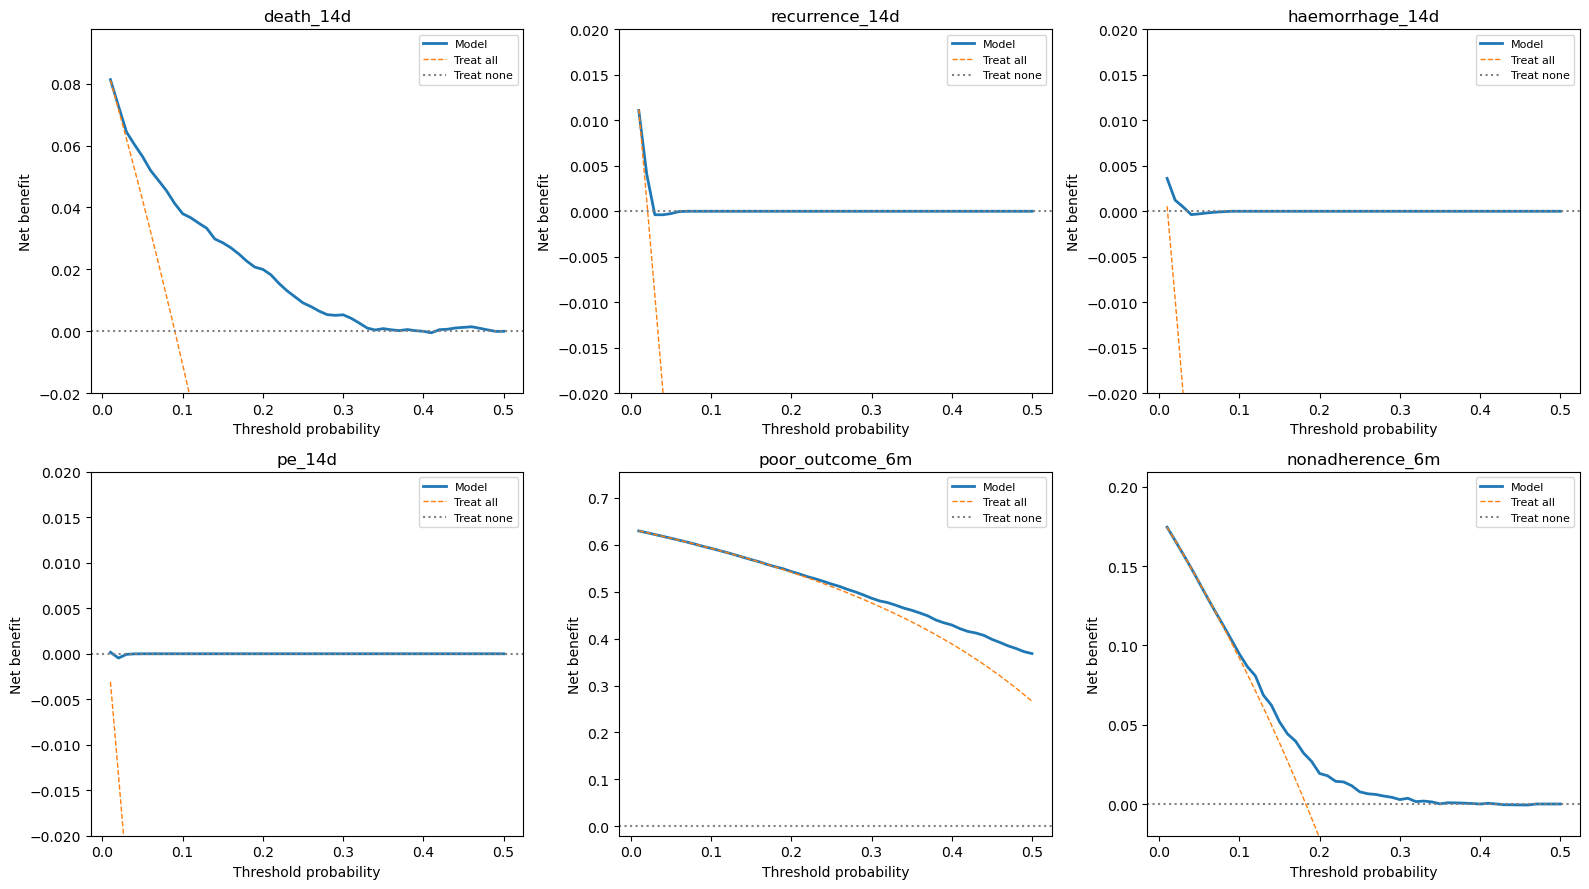

In [13]:
def net_benefit(y_true, y_prob, thresholds):
    y_true = np.asarray(y_true); n = len(y_true)
    out = []
    for t in thresholds:
        pred = y_prob >= t
        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        out.append(tp / n - (fp / n) * (t / (1 - t)))
    return np.array(out)

thresholds = np.arange(0.01, 0.51, 0.01)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

log("\n## 11. Decision curve analysis\n")
log("| Outcome | Useful threshold range | Max net benefit |")
log("|---|---|---|")

for ax, outcome in zip(axes.ravel(), OUTCOMES):
    Xte, yte = get_xy(outcome, FEATURES, test_idx)
    model = joblib.load(MODELS / f"final_{outcome}.pkl")
    p = model.predict_proba(Xte)[:, 1]

    nb_model = net_benefit(yte, p, thresholds)
    prev = float(np.mean(yte))
    nb_all = np.array([prev - (1 - prev) * (t / (1 - t)) for t in thresholds])

    ax.plot(thresholds, nb_model, label="Model", linewidth=2)
    ax.plot(thresholds, nb_all, "--", label="Treat all", linewidth=1)
    ax.axhline(0, color="grey", linestyle=":", label="Treat none")
    ax.set_title(outcome); ax.set_xlabel("Threshold probability")
    ax.set_ylabel("Net benefit"); ax.legend(fontsize=8)
    ax.set_ylim(min(-0.02, nb_model.min()), max(nb_model.max() * 1.2, 0.02))

    better = (nb_model > nb_all) & (nb_model > 0)
    rng = (f"{thresholds[better].min():.2f}–{thresholds[better].max():.2f}"
           if better.any() else "none")
    log(f"| `{outcome}` | {rng} | {nb_model.max():.4f} |")

plt.tight_layout(); plt.savefig(OUT / "decision_curves.png", dpi=140); plt.show()

## 12. Subgroup performance (fairness)

Required by TRIPOD+AI. A model that performs well overall but poorly in one age band
or sex is not ready for deployment — and it is better to find that here than to be
asked about it.

In [14]:
log("\n## 12. Subgroup performance\n")
log("| Outcome | Subgroup | n | Events | AUC |")
log("|---|---|---|---|---|")

for outcome in OUTCOMES:
    Xte, yte = get_xy(outcome, FEATURES, test_idx)
    model = joblib.load(MODELS / f"final_{outcome}.pkl")
    p = model.predict_proba(Xte)[:, 1]
    frame = Xte.copy(); frame["_y"] = yte.values; frame["_p"] = p
    frame["_age"] = pd.cut(frame["AGE"], [0, 65, 75, 200],
                           labels=["<65", "65-74", "75+"])

    for col, label in [("_age", "age"), ("SEX", "sex")]:
        for val, grp in frame.groupby(col, observed=True):
            if grp["_y"].nunique() < 2 or len(grp) < 50:
                continue
            name = val if col == "_age" else ("male" if val == 1 else "female")
            log(f"| `{outcome}` | {label} {name} | {len(grp):,} "
                f"| {int(grp['_y'].sum()):,} | {roc_auc_score(grp['_y'], grp['_p']):.3f} |")


## 12. Subgroup performance

| Outcome | Subgroup | n | Events | AUC |
|---|---|---|---|---|
| `death_14d` | age <65 | 1,038 | 65 | 0.817 |
| `death_14d` | age 65-74 | 1,248 | 78 | 0.762 |
| `death_14d` | age 75+ | 1,601 | 208 | 0.771 |
| `death_14d` | sex female | 1,830 | 178 | 0.783 |
| `death_14d` | sex male | 2,057 | 173 | 0.799 |
| `recurrence_14d` | age <65 | 1,038 | 22 | 0.618 |
| `recurrence_14d` | age 65-74 | 1,248 | 28 | 0.591 |
| `recurrence_14d` | age 75+ | 1,601 | 32 | 0.571 |
| `recurrence_14d` | sex female | 1,830 | 37 | 0.556 |
| `recurrence_14d` | sex male | 2,057 | 45 | 0.617 |
| `haemorrhage_14d` | age <65 | 1,038 | 12 | 0.584 |
| `haemorrhage_14d` | age 65-74 | 1,248 | 14 | 0.759 |
| `haemorrhage_14d` | age 75+ | 1,601 | 15 | 0.801 |
| `haemorrhage_14d` | sex female | 1,830 | 18 | 0.780 |
| `haemorrhage_14d` | sex male | 2,057 | 23 | 0.689 |
| `pe_14d` | age <65 | 1,038 | 8 | 0.588 |
| `pe_14d` | age 65-74 | 1,248 | 8 | 0.793 |
| `pe_14d` | age 75+ | 1,601 | 11 | 0

## 13. Benchmark against the trial's own prognostic estimates

IST-1 ships pre-computed predictions: `EXPD14` (14-day death) and `EXPDD`
(6-month death/dependency). Scoring them on the same test set gives a real,
contemporaneous comparator — far stronger than reporting an AUC with nothing
to compare it against.

In [15]:
log("\n## 13. Versus the trial's own estimates\n")
log("| Comparator | Outcome | Trial AUC | Our AUC |")
log("|---|---|---|---|")

for exp_col, outcome in [("EXPD14", "death_14d"), ("EXPDD", "poor_outcome_6m")]:
    Xte, yte = get_xy(outcome, FEATURES, test_idx)
    trial_p = df.loc[yte.index, exp_col]
    ok = trial_p.notna()
    trial_auc = roc_auc_score(yte[ok], trial_p[ok])
    log(f"| `{exp_col}` | `{outcome}` | {trial_auc:.3f} | {metrics[outcome]['auc']:.3f} |")


## 13. Versus the trial's own estimates

| Comparator | Outcome | Trial AUC | Our AUC |
|---|---|---|---|
| `EXPD14` | `death_14d` | 0.787 | 0.793 |
| `EXPDD` | `poor_outcome_6m` | 0.792 | 0.802 |


## 14. IST-3 external validation *(optional — diagnostic first)*

IST-3 (2000–2011) includes thrombolysis, so it addresses the era limitation of IST-1.

**Do not merge the two trials into one training set.** Era and treatment are
confounded, and IST-3 enrolled a narrower population (patients being considered for
thrombolysis). The correct use is *external validation*: score the IST-1-trained model
on IST-3 patients and see whether discrimination holds across eras.

This cell only **inspects** IST-3's coding. The column mapping cannot be written
blind — run this, then map the fields deliberately.

In [16]:
if IST3.exists():
    i3 = pd.read_csv(IST3, low_memory=False)
    print(f"IST-3: {len(i3):,} rows x {len(i3.columns)} columns\n")
    candidates = ["age", "gender", "randdelay", "sbprand", "atrialfib_rand",
                  "stroketype", "gcs_score_rand", "nihss", "treatment",
                  "dead7", "sich7", "dead6mo", "deadordep6", "aspirin6", "bloodthin6"]
    for c in candidates:
        if c in i3.columns:
            u = i3[c].dropna().unique()
            preview = u[:8] if len(u) <= 8 else f"{u[:5]} ... ({len(u)} distinct)"
            print(f"{c:18s} n={i3[c].notna().sum():5d}  {preview}")
        else:
            print(f"{c:18s} NOT PRESENT")
else:
    print("IST3_clean.csv not found — skipping (optional).")

IST-3: 3,035 rows x 266 columns

age                n= 3035  [81. 92. 75. 60. 88.] ... (58 distinct)
gender             n= 3035  [1. 2.]
randdelay          n= 3035  [3.61666667 1.86666667 5.08333333 4.33333333 1.91666667] ... (296 distinct)
sbprand            n= 3035  [145. 170. 120. 128. 177.] ... (129 distinct)
atrialfib_rand     n= 3035  [2. 1.]
stroketype         n= 3035  [2. 1. 4. 3. 5.]
gcs_score_rand     n= 3035  [13. 15. 14.  9. 12.] ... (13 distinct)
nihss              n= 3035  [10. 18.  4. 13.  6.] ... (36 distinct)
treatment          n= 3035  <ArrowStringArray>
['rt-PA', 'Placebo']
Length: 2, dtype: str
dead7              n= 3035  [0. 1.]
sich7              n= 3035  [0. 1.]
dead6mo            n= 3035  [1. 0.]
deadordep6         n= 3035  [1. 2.]
aspirin6           n= 3035  [10.  2.  1.  3. 40. 30. 20.]
bloodthin6         n= 3035  [10.  2.  3. 20. 40. 30.  1.]


## 15. Export artifacts and model card

In [17]:
(OUT / "pipeline_report.md").write_text("\n".join(report), encoding="utf-8")
(OUT / "final_metrics.json").write_text(
    json.dumps({"metrics": metrics, "top_drivers": drivers}, indent=2))

card = [
    "# RecoveryLens — Model Card", "",
    "## Intended use", "",
    "Decision support at hospital discharge after acute ischaemic stroke. Produces "
    "risk estimates for six outcomes plus the factors driving each, to help "
    "prioritise rehabilitation referral, monitoring and adherence support.",
    "",
    "**Not** for autonomous clinical decisions. Every output is advisory and assumes "
    "a clinician in the loop.", "",
    "## Training data", "",
    "International Stroke Trial (IST-1): 19,435 patients, 467 hospitals, 36 countries, "
    "recruited 1991–1996. Public and fully anonymised.", "",
    "## Model", "",
    f"L2-penalised logistic regression, {len(FEATURES)} features, one model per outcome. "
    "Selected over Random Forest, XGBoost, LightGBM and CatBoost: no gradient-boosted "
    "model beat it outside its confidence interval, and all calibrated worse on the "
    "rare outcomes.", "",
    "## Performance (held-out test set)", "",
    "| Outcome | Events | AUC (95% CI) | Cal. slope | CITL |",
    "|---|---|---|---|---|",
]
for k, m in metrics.items():
    card.append(f"| {k} | {m['events']:,} | {m['auc']:.3f} "
                f"({m['ci'][0]:.3f}–{m['ci'][1]:.3f}) | {m['cal_slope']:.2f} "
                f"| {m['citl']:+.3f} |")

card += [
    "", "## Limitations", "",
    "- **Vintage.** IST-1 predates routine thrombolysis (14 of 19,435 patients "
    "received it) and modern stroke units. Absolute probabilities require "
    "recalibration before contemporary use. Discrimination — the ranking of who is "
    "higher risk — transfers more reliably than calibration.",
    "- **No NIHSS.** IST-1 records consciousness on a three-level scale rather than a "
    "formal severity score. Published models reaching AUC ~0.85 (ASTRAL, PLAN) use "
    "NIHSS; that gap is a data limitation, not a modelling one.",
    "- **`recurrence_14d` is weak** and should be presented as exploratory. Early "
    "ischaemic recurrence appears largely unpredictable from presentation alone.",
    "- **Low EPV** on `haemorrhage_14d` and `pe_14d`. Confidence intervals are wide "
    "and reported as such.",
    "- **Population.** Predominantly European recruitment; performance in South Asian "
    "populations is unvalidated.",
    "", "## Deployment status", "",
    "Research prototype. Not validated prospectively, and not approved for clinical "
    "use. Real deployment would require local recalibration, a silent validation "
    "period with predictions logged but not acted upon, and institutional ethics "
    "approval.",
]
(OUT / "MODEL_CARD.md").write_text("\n".join(card), encoding="utf-8")
print("Wrote outputs/pipeline_report.md, final_metrics.json, MODEL_CARD.md")

Wrote outputs/pipeline_report.md, final_metrics.json, MODEL_CARD.md


## 16. Summary — paste this back for review

In [18]:
print("=" * 72)
print("RECOVERYLENS — PIPELINE SUMMARY")
print("=" * 72)
print(f"\nRows {len(df):,} | Features {len(FEATURES)} | Parameters {n_params}")
print(f"Split: {len(train_idx):,} train / {len(test_idx):,} test\n")

print(f"{'Outcome':20s} {'Events':>7s} {'AUC':>7s} {'95% CI':>16s} "
      f"{'Slope':>7s} {'CITL':>7s}")
print("-" * 72)
for k, m in metrics.items():
    ci = f"{m['ci'][0]:.3f}-{m['ci'][1]:.3f}"
    print(f"{k:20s} {m['events']:7,d} {m['auc']:7.3f} {ci:>16s} "
          f"{m['cal_slope']:7.2f} {m['citl']:+7.3f}")

print("\nBest family per outcome (benchmark):")
for outcome in OUTCOMES:
    s = bench[bench.outcome == outcome].sort_values("test_auc", ascending=False)
    b = s.iloc[0]; base = s[s.family == "Logistic (L2)"].iloc[0]
    earned = "—" if b.family == "Logistic (L2)" else (
        "beats CI" if b.test_auc > base.ci_hi else "inside CI")
    print(f"  {outcome:20s} {b.family:16s} {b.test_auc:.3f}  ({earned})")

print("\nTop drivers:")
for k, v in drivers.items():
    print(f"  {k:20s} {', '.join(v[:3])}")
print("\n" + "=" * 72)

RECOVERYLENS — PIPELINE SUMMARY

Rows 19,435 | Features 24 | Parameters 29
Split: 15,548 train / 3,887 test

Outcome               Events     AUC           95% CI   Slope    CITL
------------------------------------------------------------------------
death_14d              1,430   0.793      0.769-0.818    0.94  -0.025
recurrence_14d           313   0.590      0.530-0.646    0.69  +0.051
haemorrhage_14d          120   0.732      0.660-0.802    0.91  +0.330
pe_14d                   107   0.666      0.580-0.752    0.78  +0.010
poor_outcome_6m        9,679   0.802      0.787-0.815    1.04  +0.045
nonadherence_6m        1,901   0.626      0.600-0.652    0.98  +0.109

Best family per outcome (benchmark):
  death_14d            Logistic (L2)    0.793  (—)
  recurrence_14d       Random Forest    0.593  (inside CI)
  haemorrhage_14d      Logistic (L2)    0.732  (—)
  pe_14d               CatBoost         0.702  (inside CI)
  poor_outcome_6m      CatBoost         0.802  (inside CI)
  nonadhere